# Abstract Signal Mixing — Two Risk Factors at an Angle

We build a fully abstract insurance dataset:
1. **N** standard-Gaussian features
2. Two latent risk factors constructed as linear combinations of those features, separated by an angle **θ**
3. Poisson claim counts drawn directly (no library helper) for each factor
4. A combined claim column

## 0. Parameters

All tuneable knobs live here — change them and re-run.

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import claimssimulator as csim
from claimssimulator.metrics import gini, calibration_quality_ratio as cqr

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# ── Experiment parameters ─────────────────────────────────────
N_FEATURES       = 6          # number of Gaussian features
N_SAMPLES        = 10_000     # number of policies
CONTRACT_MEAN    = 5.0        # mean contract duration (years, Exponential)
CONTRACT_MAX     = 10.0       # cap on contract duration
THETA_DEG        = 30        # angle (degrees) between the two risk directions
FREQ_1           = 0.05       # base frequency for risk factor 1
FREQ_2           = 0.005       # base frequency for risk factor 2
NOISE_RATIO      = 0.5        # fraction of log-risk variance from unobserved noise
                              # (0.0 = fully observable, 0.5 = half hidden)
SEED             = 42


## 1. Feature Specification

We define **N** i.i.d. standard-Normal features plus an Exponential contract duration.

In [26]:
feature_spec = [
    csim.Feature(f'x{i}', csim.Normal(loc=0, scale=1))
    for i in range(N_FEATURES)
]

feature_spec.append(
    csim.Feature(
        'contract_duration_years',
        csim.Exponential(scale=CONTRACT_MEAN),
        csim.Transform(lambda x: np.clip(x, 0.1, CONTRACT_MAX)),
    )
)

feat_def = csim.FeatureDefinition(feature_spec)
df = feat_def.generate(n_samples=N_SAMPLES, random_seed=SEED)

print(f"Generated {len(df):,} policies  ·  {len(df.columns)} columns")
df.head()

Generated 10,000 policies  ·  7 columns


,x0,x1,x2,x3,x4,x5,contract_duration_years
0,0.304717,0.176277,-1.658201,-1.011428,-0.899768,0.769680,5.264864
1,-1.039984,0.899123,0.891207,-0.047397,-1.258172,-1.843905,1.573755
2,0.750451,-1.472271,-0.058032,-1.346366,0.332616,-0.239658,1.686059
3,0.940565,-0.285298,-0.599909,-0.715356,0.153343,-1.090636,5.190288
4,-1.951035,0.829153,-0.250818,-0.244191,-2.224559,2.863653,10.000000


## 2. Build Two Risk Directions Separated by Angle θ

We pick a random unit vector **w₁** in ℝᴺ for the first factor.
The second vector **w₂** is constructed so that `cos(θ) = w₁ · w₂`, giving a controlled correlation between the two risk scores.

In [27]:
theta = np.deg2rad(THETA_DEG)
rng = np.random.default_rng(SEED)

# Random unit vector w1
w1 = rng.standard_normal(N_FEATURES)
w1 = w1 / np.linalg.norm(w1)

# Build w2 at angle theta from w1
# w2 = cos(theta)*w1 + sin(theta)*w_perp
w_rand = rng.standard_normal(N_FEATURES)
w_perp = w_rand - w_rand.dot(w1) * w1          # component orthogonal to w1
w_perp = w_perp / np.linalg.norm(w_perp)
w2 = np.cos(theta) * w1 + np.sin(theta) * w_perp

print(f"w1 · w2 = {w1.dot(w2):.4f}  (expected cos({THETA_DEG}°) = {np.cos(theta):.4f})")
print(f"w1 = {np.round(w1, 3)}")
print(f"w2 = {np.round(w2, 3)}")

w1 · w2 = 0.8660  (expected cos(30°) = 0.8660)
w1 = [ 0.107 -0.365  0.263  0.33  -0.684 -0.457]
w2 = [ 0.217 -0.681  0.368  0.041 -0.534 -0.26 ]


In [28]:
# Compute the linear risk scores (zero-mean, unit-variance projections)
X = df[[f'x{i}' for i in range(N_FEATURES)]].values

signal_1 = X @ w1
signal_2 = X @ w2

# Add unobserved heterogeneity controlled by NOISE_RATIO
# log_risk_k = sqrt(1 - NOISE_RATIO) * signal_k + sqrt(NOISE_RATIO) * noise_k
noise_1 = rng.standard_normal(N_SAMPLES)
noise_2 = rng.standard_normal(N_SAMPLES)

df['risk_factor_1'] = np.sqrt(1 - NOISE_RATIO) * signal_1 + np.sqrt(NOISE_RATIO) * noise_1
df['risk_factor_2'] = np.sqrt(1 - NOISE_RATIO) * signal_2 + np.sqrt(NOISE_RATIO) * noise_2

print(f"NOISE_RATIO = {NOISE_RATIO}  →  {(1-NOISE_RATIO)*100:.0f}% of log-risk variance is observable")
print(f"Risk factor 1  — mean: {df['risk_factor_1'].mean():.3f},  std: {df['risk_factor_1'].std():.3f}")
print(f"Risk factor 2  — mean: {df['risk_factor_2'].mean():.3f},  std: {df['risk_factor_2'].std():.3f}")
print(f"Correlation    — {df['risk_factor_1'].corr(df['risk_factor_2']):.4f}")

NOISE_RATIO = 0.5  →  50% of log-risk variance is observable
Risk factor 1  — mean: -0.001,  std: 1.000
Risk factor 2  — mean: 0.015,  std: 1.002
Correlation    — 0.4272


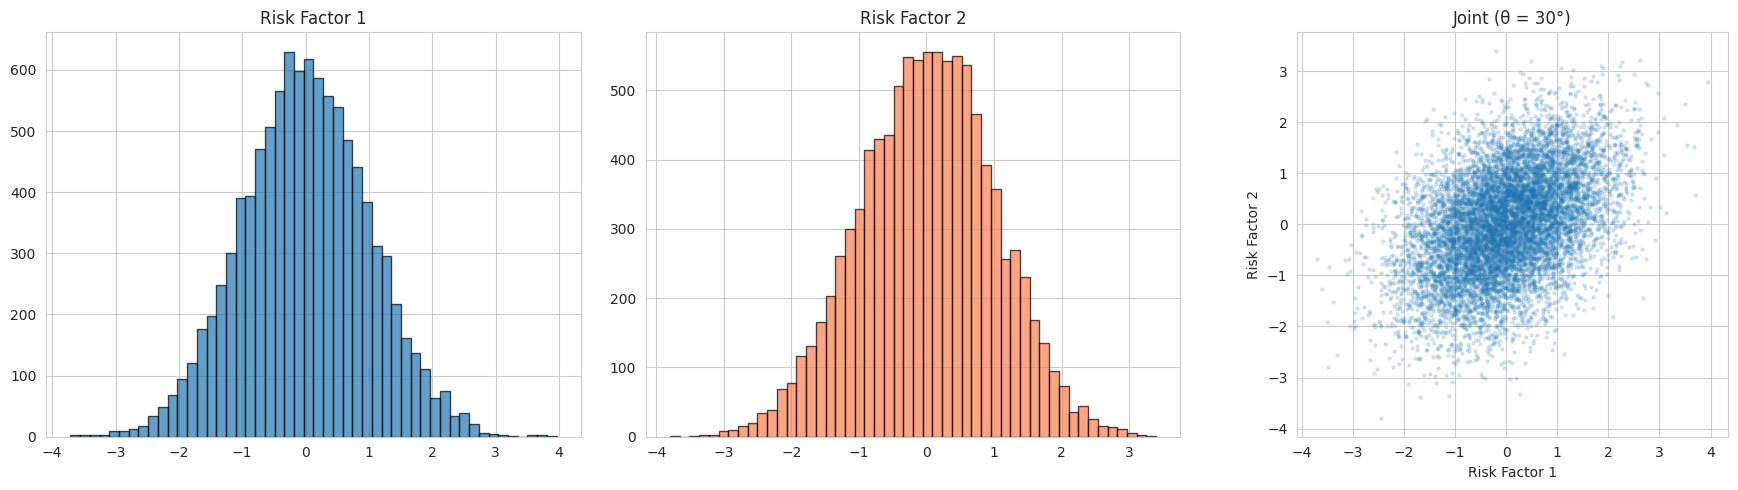

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['risk_factor_1'], bins=50, edgecolor='k', alpha=0.7)
axes[0].set_title('Risk Factor 1')

axes[1].hist(df['risk_factor_2'], bins=50, edgecolor='k', alpha=0.7, color='coral')
axes[1].set_title('Risk Factor 2')

axes[2].scatter(df['risk_factor_1'], df['risk_factor_2'], alpha=0.15, s=5)
axes[2].set_xlabel('Risk Factor 1')
axes[2].set_ylabel('Risk Factor 2')
axes[2].set_title(f'Joint (θ = {THETA_DEG}°)')
axes[2].set_aspect('equal')

plt.tight_layout()
plt.show()

## 3. Simulate Claim Counts (Directly via Poisson)

For each policy we draw Poisson counts using:
$$\lambda_k = \text{freq}_k \times \exp(\text{risk\_factor}_k) \times \text{exposure}$$

where `exposure = contract_duration_years`.

In [30]:
import importlib, claimssimulator.simulation
importlib.reload(claimssimulator.simulation)
from claimssimulator.simulation import ClaimSource, MultiCauseClaimsSimulator

# Attach per-policy *rates* (claims per year) as plain columns.
# The per-year rate is FREQ_k * exp(risk_k).
df['rate_1'] = FREQ_1 * np.exp(df['risk_factor_1'].values)
df['rate_2'] = FREQ_2 * np.exp(df['risk_factor_2'].values)

sources = [
    ClaimSource(
        name='source_1',
        generator='Poisson',
        param_columns={'rate': 'rate_1'},
    ),
    ClaimSource(
        name='source_2',
        generator='Poisson',
        param_columns={'rate': 'rate_2'},
    ),
]

mc_sim = MultiCauseClaimsSimulator(
    sources=sources,
    time_to_simulate='contract_duration_years',
    max_exposure=1.0,
    exposure_column='exposure',
    claim_counter='past_claims',
    renewal_mode='contract_end',
    random_seed=SEED,
)

claim_df = mc_sim.simulate(df)

# Rename for consistency with the rest of the notebook
claim_df = claim_df.rename(columns={
    'claim_source_1': 'claims_1',
    'claim_source_2': 'claims_2',
})

# Combined claim column
claim_df['claims_total'] = claim_df['claims_1'] + claim_df['claims_2']

print(f"Contracts : {len(df):,}")
print(f"Rows      : {len(claim_df):,}  ({len(claim_df)/len(df):.2f}× expansion)")
print(f"Factor 1 — total claims: {claim_df['claims_1'].sum():,}  "
      f"rate: {claim_df['claims_1'].sum() / claim_df['exposure'].sum():.4f}")
print(f"Factor 2 — total claims: {claim_df['claims_2'].sum():,}  "
      f"rate: {claim_df['claims_2'].sum() / claim_df['exposure'].sum():.4f}")
print(f"Combined — total claims: {claim_df['claims_total'].sum():,}  "
      f"rate: {claim_df['claims_total'].sum() / claim_df['exposure'].sum():.4f}")
print(f"\nMax claims per row: {claim_df[['claims_1','claims_2']].sum(axis=1).max()}  "
      f"(always ≤ 1 by competing-risks design)")

Contracts : 10,000
Rows      : 51,573  (5.16× expansion)
Factor 1 — total claims: 3,514  rate: 0.0812
Factor 2 — total claims: 324  rate: 0.0075
Combined — total claims: 3,838  rate: 0.0887

Max claims per row: 1  (always ≤ 1 by competing-risks design)


## 4. Quick Diagnostics

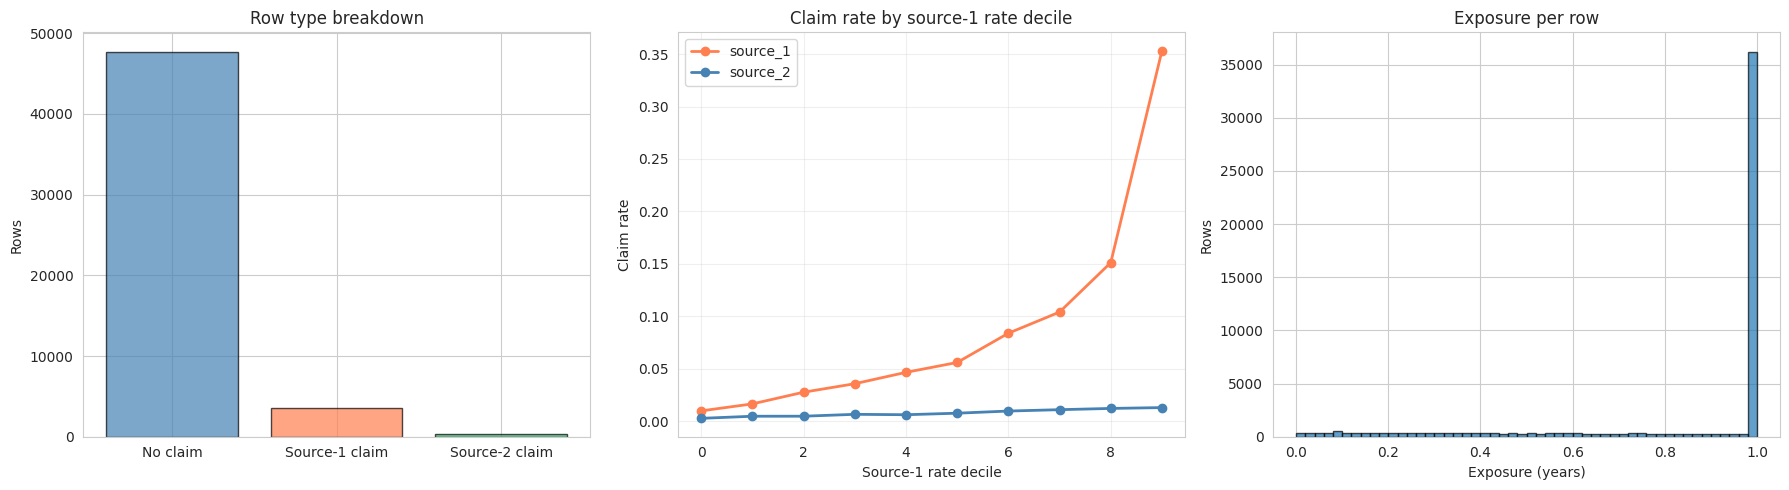

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Row type breakdown
claim_counts = {
    'No claim':        ((claim_df['claims_1'] == 0) & (claim_df['claims_2'] == 0)).sum(),
    'Source-1 claim':  claim_df['claims_1'].sum(),
    'Source-2 claim':  claim_df['claims_2'].sum(),
}
axes[0].bar(claim_counts.keys(), claim_counts.values(), edgecolor='k', alpha=0.7,
            color=['steelblue', 'coral', 'mediumseagreen'])
axes[0].set_title('Row type breakdown')
axes[0].set_ylabel('Rows')

# 2. Claim rate by source-1 risk decile
decile_1 = pd.qcut(claim_df['rate_1'], q=10, labels=False, duplicates='drop')
for label, col, color in [('source_1', 'claims_1', 'coral'),
                           ('source_2', 'claims_2', 'steelblue')]:
    rate = claim_df.groupby(decile_1).apply(
        lambda g: g[col].sum() / g['exposure'].sum()
    )
    axes[1].plot(rate.index, rate.values, marker='o', linewidth=2, label=label, color=color)
axes[1].set_title('Claim rate by source-1 rate decile')
axes[1].set_xlabel('Source-1 rate decile')
axes[1].set_ylabel('Claim rate')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Exposure per row distribution
axes[2].hist(claim_df['exposure'], bins=50, edgecolor='k', alpha=0.7)
axes[2].set_title('Exposure per row')
axes[2].set_xlabel('Exposure (years)')
axes[2].set_ylabel('Rows')

plt.tight_layout()
plt.show()

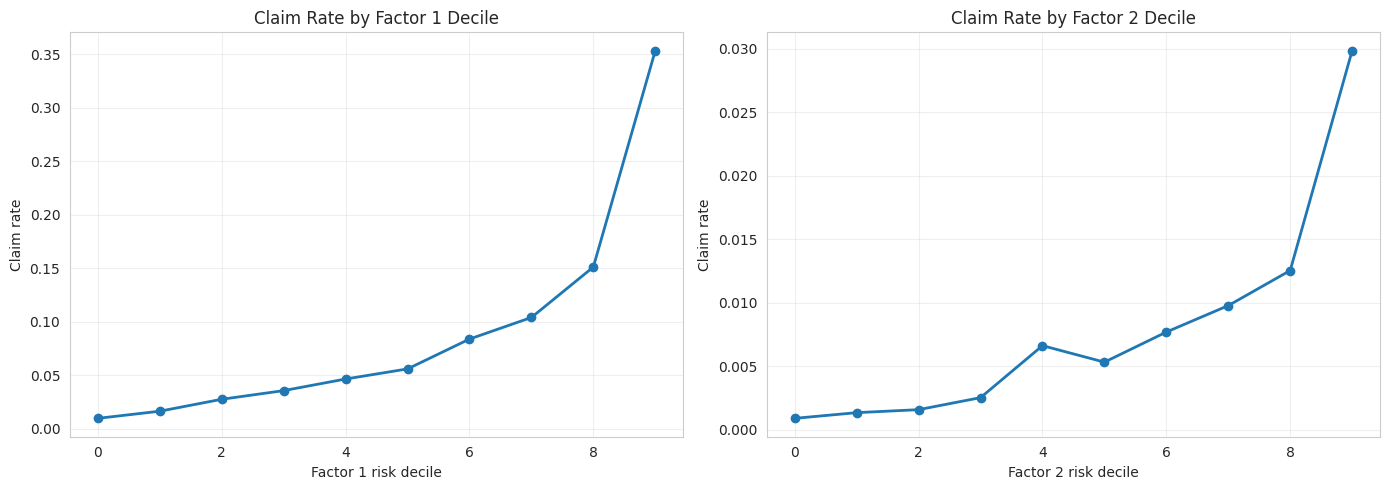

In [32]:
# Claim rate by risk-score decile
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, risk_col, claim_col, lbl in zip(
    axes,
    ['risk_factor_1', 'risk_factor_2'],
    ['claims_1', 'claims_2'],
    ['Factor 1', 'Factor 2'],
):
    decile = pd.qcut(claim_df[risk_col], q=10, labels=False, duplicates='drop')
    rate = claim_df.groupby(decile).apply(
        lambda g: g[claim_col].sum() / g['exposure'].sum()
    )
    ax.plot(rate.index, rate.values, marker='o', linewidth=2)
    ax.set_xlabel(f'{lbl} risk decile')
    ax.set_ylabel('Claim rate')
    ax.set_title(f'Claim Rate by {lbl} Decile')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [33]:
claim_df[['risk_factor_1', 'risk_factor_2', 'rate_1', 'rate_2', 
          'exposure', 'past_claims', 'claims_1', 'claims_2', 'claims_total']].head(15)

,risk_factor_1,risk_factor_2,rate_1,rate_2,exposure,past_claims,claims_1,claims_2,claims_total
0,-0.333604,-0.016938,0.035817,0.004916,1.000000,0,0,0,0
1,-0.333604,-0.016938,0.035817,0.004916,1.000000,0,0,0,0
2,-0.333604,-0.016938,0.035817,0.004916,1.000000,0,0,0,0
3,-0.333604,-0.016938,0.035817,0.004916,1.000000,0,0,0,0
4,-0.333604,-0.016938,0.035817,0.004916,1.000000,0,0,0,0
5,-0.333604,-0.016938,0.035817,0.004916,0.264864,0,0,0,0
6,1.845973,0.978553,0.316713,0.013303,1.000000,0,0,0,0
7,1.845973,0.978553,0.316713,0.013303,0.573755,0,0,0,0
8,0.358624,0.113103,0.071568,0.005599,1.000000,0,0,0,0
9,0.358624,0.113103,0.071568,0.005599,0.686059,0,0,0,0


## 5. Train EBM Poisson Regressors

We train three models, all with Poisson deviance objective and exposure as sample weight, using the `claim_df` generated by `MultiCauseClaimsSimulator` in Section 3:

| Model | Target | Description |
|---|---|---|
| `ebm_combined` | `claims_total` | One model for the blended signal |
| `ebm_1` | `claims_1` | Specialist for factor-1 risk |
| `ebm_2` | `claims_2` | Specialist for factor-2 risk |

The sum of the two specialists (`ebm_1 + ebm_2`) forms a fourth predictor.

In [34]:
from sklearn.model_selection import train_test_split
from interpret.glassbox import ExplainableBoostingRegressor

feature_cols = [f'x{i}' for i in range(N_FEATURES)]

# Split at the policy (contract_id) level
unique_contracts = claim_df['contract_id'].unique()
contracts_train, contracts_test = train_test_split(unique_contracts, test_size=0.25, random_state=SEED)

train = claim_df[claim_df['contract_id'].isin(contracts_train)].copy()
test  = claim_df[claim_df['contract_id'].isin(contracts_test)].copy()

X_train = train[feature_cols]
X_test  = test[feature_cols]
w_train = train['exposure']
w_test  = test['exposure']

print(f"Train: {len(train):,} rows  ({train['claims_total'].sum():,.0f} total claims)")
print(f"Test : {len(test):,} rows   ({test['claims_total'].sum():,.0f} total claims)")

EBM_PARAMS = dict(max_bins=64, max_rounds=300, learning_rate=0.05,
                  objective='poisson_deviance', random_state=SEED)

# ── combined model ──────────────────────────────────────────
ebm_combined = ExplainableBoostingRegressor(**EBM_PARAMS)
ebm_combined.fit(X_train, train['claims_total'] / w_train, sample_weight=w_train)
print("ebm_combined  ✓")

# ── specialist: factor 1 ────────────────────────────────────
ebm_1 = ExplainableBoostingRegressor(**EBM_PARAMS)
ebm_1.fit(X_train, train['claims_1'] / w_train, sample_weight=w_train)
print("ebm_1         ✓")

# ── specialist: factor 2 ────────────────────────────────────
ebm_2 = ExplainableBoostingRegressor(**EBM_PARAMS)
ebm_2.fit(X_train, train['claims_2'] / w_train, sample_weight=w_train)
print("ebm_2         ✓")

Train: 38,769 rows  (2,940 total claims)
Test : 12,804 rows   (898 total claims)
ebm_combined  ✓
ebm_combined  ✓
ebm_1         ✓
ebm_1         ✓
ebm_2         ✓
ebm_2         ✓


## 6. Cause Classifier + Performance Tables

Beyond the three frequency regressors we train a **cause classifier**: given that *a claim occurred*, what is the probability it came from source 1 vs source 2?

- Trained only on claim rows (`claims_total == 1`)
- Binary target: `claims_1` (1 = source-1, 0 = source-2)
- An EBM classifier with log-loss objective

This lets us split the combined model prediction:
- `ebm_combined × P(source 1 | claim)` — estimated source-1 frequency
- `ebm_combined × P(source 2 | claim)` — estimated source-2 frequency

**Rows** = targets: `claims_total`, `claims_1`, `claims_2`  
**Columns** = predictors: `ebm_combined`, `ebm_1`, `ebm_2`, `ebm_1+ebm_2`, `ebm_combined×p1`, `ebm_combined×p2`

In [35]:
from interpret.glassbox import ExplainableBoostingClassifier

# ── Cause classifier: trained on claim rows only ────────────
train_claims = train[train['claims_total'] == 1].copy()
test_claims  = test[test['claims_total'] == 1].copy()

ebm_cause = ExplainableBoostingClassifier(
    max_bins=64,
    max_rounds=300,
    learning_rate=0.05,
    random_state=SEED,
)
ebm_cause.fit(train_claims[feature_cols], train_claims['claims_1'])
print(f"Cause classifier trained  ✓   "
      f"(on {len(train_claims):,} claim rows  —  "
      f"{train_claims['claims_1'].mean()*100:.1f}% source-1)")

# ── Predictions on full test set ────────────────────────────
pred_combined = ebm_combined.predict(X_test)
pred_s1       = ebm_1.predict(X_test)
pred_s2       = ebm_2.predict(X_test)
pred_sum      = pred_s1 + pred_s2

# P(source 1 | claim) and P(source 2 | claim) for every test row
proba_source1 = ebm_cause.predict_proba(X_test)[:, 1]   # P(class=1) = P(source 1)
proba_source2 = 1.0 - proba_source1

pred_comb_p1  = pred_combined * proba_source1
pred_comb_p2  = pred_combined * proba_source2

predictors = {
    'ebm_combined':     pred_combined,
    'ebm_1':            pred_s1,
    'ebm_2':            pred_s2,
    'ebm_1 + ebm_2':    pred_sum,
    'ebm_comb × p1':    pred_comb_p1,
    'ebm_comb × p2':    pred_comb_p2,
}

targets = {
    'claims_total': test['claims_total'].values,
    'claims_1':     test['claims_1'].values,
    'claims_2':     test['claims_2'].values,
}

w = w_test.values

# ── Build tables ─────────────────────────────────────────────
def make_table(metric_fn, **kwargs):
    rows = {}
    for t_name, t_vals in targets.items():
        row = {}
        for p_name, p_vals in predictors.items():
            row[p_name] = metric_fn(t_vals, p_vals, w, **kwargs)
        rows[t_name] = row
    return pd.DataFrame(rows).T

gini_table = make_table(gini)
cqr_table  = make_table(cqr, n_bins=20, method='mse', norm='sqrt')

print("\n=== Gini ===")
display(gini_table.style.format("{:.4f}").background_gradient(cmap='RdYlGn', axis=1))

print("\n=== CQR (n_bins=20, mse, sqrt) ===")
display(cqr_table.style.format("{:.4f}").background_gradient(cmap='RdYlGn', axis=1))


Cause classifier trained  ✓   (on 2,940 claim rows  —  91.8% source-1)

=== Gini ===


,ebm_combined,ebm_1,ebm_2,ebm_1 + ebm_2,ebm_comb × p1,ebm_comb × p2
claims_total,0.3463,0.3463,0.3180,0.3481,0.3461,0.3282
claims_1,0.3492,0.3489,0.3163,0.3506,0.3491,0.3287
claims_2,0.3178,0.3199,0.3351,0.3238,0.3163,0.3228



=== CQR (n_bins=20, mse, sqrt) ===


,ebm_combined,ebm_1,ebm_2,ebm_1 + ebm_2,ebm_comb × p1,ebm_comb × p2
claims_total,0.2230,0.2242,0.2122,0.2233,0.2234,0.2180
claims_1,0.2516,0.2528,0.2434,0.2520,0.2520,0.2477
claims_2,0.7522,0.7523,0.7516,0.7522,0.7522,0.7519


In [36]:
import pickle
from datetime import datetime
from pathlib import Path

RESULTS_PATH = Path('../../data/signal_mixing_experiments.pkl')

# ── Bundle this experiment ────────────────────────────────────
experiment = {
    'timestamp': datetime.now().isoformat(),
    'params': {
        'N_FEATURES':    N_FEATURES,
        'N_SAMPLES':     N_SAMPLES,
        'CONTRACT_MEAN': CONTRACT_MEAN,
        'CONTRACT_MAX':  CONTRACT_MAX,
        'THETA_DEG':     THETA_DEG,
        'FREQ_1':        FREQ_1,
        'FREQ_2':        FREQ_2,
        'SEED':          SEED,
    },
    'w1': w1,
    'w2': w2,
    'gini': gini_table,
    'cqr':  cqr_table,
}

# ── Load existing results or start fresh ─────────────────────
if RESULTS_PATH.exists():
    with open(RESULTS_PATH, 'rb') as f:
        all_results = pickle.load(f)
else:
    all_results = []

all_results.append(experiment)

with open(RESULTS_PATH, 'wb') as f:
    pickle.dump(all_results, f)

print(f"Saved experiment #{len(all_results)}  →  {RESULTS_PATH}")
print(f"  params : {experiment['params']}")
print(f"  stored experiments so far: {len(all_results)}")

Saved experiment #7  →  ../../data/signal_mixing_experiments.pkl
  params : {'N_FEATURES': 6, 'N_SAMPLES': 10000, 'CONTRACT_MEAN': 5.0, 'CONTRACT_MAX': 10.0, 'THETA_DEG': 30, 'FREQ_1': 0.05, 'FREQ_2': 0.005, 'SEED': 42}
  stored experiments so far: 7
